Connecting Google Drive to the notebook

In [ ]:
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [ ]:
import pandas as pd
df = pd.read_csv('/content/drive/My Drive/wine_data.csv')

df.info() used for seeing column types

In [ ]:
display(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


None

To check if there is any missing values in the data

In [ ]:
display(df.isnull().sum())


,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0




>To drop any missing value if any







In [ ]:
df=df.dropna()

**Question 1**

For finding the quality occuring frequently,the highest and the lowest


In [ ]:
more_frequent=df['quality'].mode()[0]
highest_number=df['quality'].max()
lowest_number=df['quality'].min()
print(f"The most frequent quality is:{more_frequent}")
print(f"The highest quality is:{highest_number}")
print(f"The lowest quality is:{lowest_number}")

The most frequent quality is:5
The highest quality is:8
The lowest quality is:3


**Question 2**

Correlation of fixed acidity and free sulfur dioxide with quality of wine

In [ ]:
fixedq_corr=df['fixed acidity'].corr(df['quality'])
print(f"Correlation of acidity with quality: {fixedq_corr}")
freesulphur_corr=df['free sulfur dioxide'].corr(df['quality'])
print(f"Correlation of free sulfur dioxide with quality: {freesulphur_corr}")


Correlation of acidity with quality: 0.12405164911322428
Correlation of free sulfur dioxide with quality: -0.0506560572442763


Alcohol content affecting quality of the wine

*Using grouped mean,we can get the average alcohol level per quality score*


In [ ]:
print(df.groupby('quality')['alcohol'].mean())

quality
3     9.955000
4    10.265094
5     9.899706
6    10.629519
7    11.465913
8    12.094444
Name: alcohol, dtype: float64


**Question 3**

In [ ]:
print(df.groupby('quality')['residual sugar'].mean())

quality
3    2.635000
4    2.694340
5    2.528855
6    2.477194
7    2.720603
8    2.577778
Name: residual sugar, dtype: float64


In [ ]:
best = df['quality'].max()
worst = df['quality'].min()

best_sugar = df[df['quality'] == best]['residual sugar'].mean()
worst_sugar = df[df['quality'] == worst]['residual sugar'].mean()

print(f"Best quality ({best}): {best_sugar:.4f} g/L")
print(f"Lowest quality ({worst}): {worst_sugar:.4f} g/L")

Best quality (8): 2.5778 g/L
Lowest quality (3): 2.6350 g/L


**Question 4**

In [ ]:
volatilea_corr=df['volatile acidity'].corr(df['quality'])
print(volatilea_corr)

-0.390557780264007


In [ ]:
print(df.groupby('quality')['volatile acidity'].mean())

quality
3    0.884500
4    0.693962
5    0.577041
6    0.497484
7    0.403920
8    0.423333
Name: volatile acidity, dtype: float64


**Question 5**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,classification_report

In [ ]:
# Separate features (X) and target (y)
X = df.drop('quality', axis=1) # All columns except quality
y = df['quality'] # Only quality column

In [ ]:
#Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:
# Create Decision Tree Classifier
dt_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=5  # Limit depth to prevent overfitting
)

# Train the model
print("Training Decision Tree...")
dt_model.fit(X_train, y_train)
print("Decision Tree trained!")

# Make predictions
y_train_pred_dt = dt_model.predict(X_train)
y_test_pred_dt = dt_model.predict(X_test)

print("Predictions made!")

Training Decision Tree...
Decision Tree trained!
Predictions made!


In [ ]:
# Create Random Forest Classifier
rf_model = RandomForestClassifier(
    n_estimators=100,      # Number of trees
    random_state=42,
    max_depth=12,          # Limit depth of each tree
    n_jobs=-1              # Use all CPU cores for speed
)

# Train the model
print("Training Random Forest...")
rf_model.fit(X_train, y_train)
print("Random Forest trained!")

# Make predictions
y_train_pred_rf = rf_model.predict(X_train)
y_test_pred_rf = rf_model.predict(X_test)

print("Predictions made!")

Training Random Forest...
Random Forest trained!
Predictions made!


In [ ]:
# Calculate accuracy for Decision Tree
dt_train_accuracy = accuracy_score(y_train, y_train_pred_dt)
dt_test_accuracy = accuracy_score(y_test, y_test_pred_dt)

# Calculate accuracy for Random Forest
rf_train_accuracy = accuracy_score(y_train, y_train_pred_rf)
rf_test_accuracy = accuracy_score(y_test, y_test_pred_rf)

print("\n" + "="*60)
print("DECISION TREE RESULTS")
print("="*60)
print(f"Training Accuracy: {dt_train_accuracy:.4f} ({dt_train_accuracy*100:.2f}%)")
print(f"Test Accuracy:     {dt_test_accuracy:.4f} ({dt_test_accuracy*100:.2f}%)")

print("\n" + "="*60)
print("RANDOM FOREST RESULTS")
print("="*60)
print(f"Training Accuracy: {rf_train_accuracy:.4f} ({rf_train_accuracy*100:.2f}%)")
print(f"Test Accuracy:     {rf_test_accuracy:.4f} ({rf_test_accuracy*100:.2f}%)")


DECISION TREE RESULTS
Training Accuracy: 0.6724 (67.24%)
Test Accuracy:     0.5594 (55.94%)

RANDOM FOREST RESULTS
Training Accuracy: 0.9883 (98.83%)
Test Accuracy:     0.6594 (65.94%)


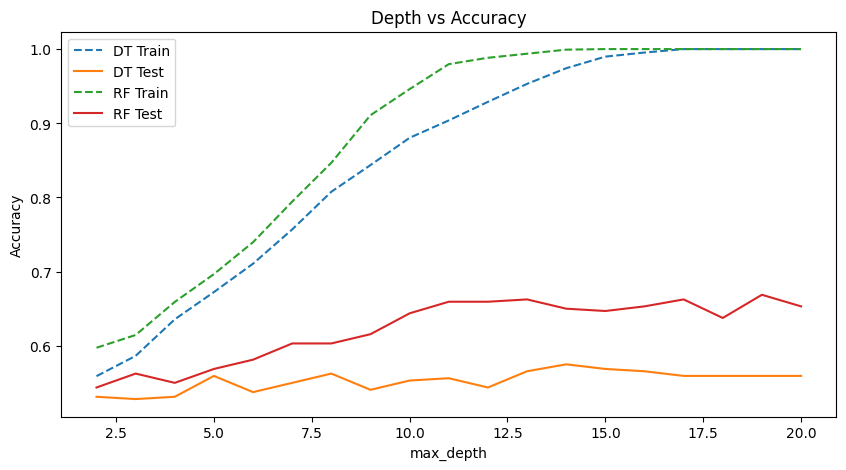

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

depths = range(2, 21)
dt_train, dt_test = [], []
rf_train, rf_test = [], []

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt.fit(X_train, y_train)
    dt_train.append(accuracy_score(y_train, dt.predict(X_train)))
    dt_test.append(accuracy_score(y_test, dt.predict(X_test)))

    rf = RandomForestClassifier(n_estimators=100, max_depth=d, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    rf_train.append(accuracy_score(y_train, rf.predict(X_train)))
    rf_test.append(accuracy_score(y_test, rf.predict(X_test)))

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.plot(depths, dt_train, label='DT Train', linestyle='--')
plt.plot(depths, dt_test, label='DT Test')
plt.plot(depths, rf_train, label='RF Train', linestyle='--')
plt.plot(depths, rf_test, label='RF Test')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Depth vs Accuracy')
plt.show()